[![Apri in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/riccardoberta/regressione/blob/main/03_lo_scout_migliora.ipynb)

# Lo scout migliora

Uno scout vero non guarda mai un solo numero. Quando deve giudicare un calciatore mette insieme età, livello tecnico, prospettive di crescita, salario, e tante altre informazioni. Il nostro scout automatico, finora, ne usa una sola: l'overall. È un buon punto di partenza, ma è ovviamente limitato. In questo notebook lo facciamo crescere e gli daremo da masticare quattro indizi contemporaneamente, per vedere se l'errore diminuisce. Prima di tutto però dobbiamo preparare i dati e pulire il dataset.

In [1]:
# Librerie necessarie per scaricare ed estrarre il dataset
import urllib.request, zipfile
from pathlib import Path

# Librerie per l'analisi dei dati e la visualizzazione
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Link al dataset e percorsi locali
DATA_URL = (
    "https://www.dropbox.com/scl/fi/0l5n46qjwcd5moj3w7d8p/"
    "fifa.zip?rlkey=rcqhagvq5ttlvna5t5r3vn1bm&st=uzplzs5o&dl=1"
)
ZIP_PATH = Path("fifa.zip")
DATA_DIR = Path("fifa_data")

# Scarichiamo il dataset se non è già presente
if not ZIP_PATH.exists():
    print("Scarico il dataset...")
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)

# Estraiamo il dataset se non è già stato fatto
if not list(DATA_DIR.rglob("*.csv")):
    DATA_DIR.mkdir(exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(DATA_DIR)

# Cerchiamo il file CSV dei giocatori dentro la cartella estratta
csv_files = (
    list(DATA_DIR.rglob("players_22.csv"))
    or list(DATA_DIR.rglob("*players*.csv"))
)

# Carichiamo il CSV in un DataFrame pandas: ogni riga = un giocatore
raw_data = pd.read_csv(csv_files[0], low_memory=False)

# Definiamo un sottoinsieme di colonne che ci interessano
wanted_columns = [
    "short_name", "age", "overall", "potential", "wage_eur", "value_eur",
    "club_name", "league_name", "player_positions"
]

# Prendiamo solo le colonne che ci interessano e copiamo il dataset
# per lavorarci sopra senza modificare l'originale
dataset = raw_data[wanted_columns].copy()

# Manteniamo solo i giocatori con valore noto e positivo
dataset = dataset.dropna(subset=["value_eur", "age", "overall", "potential"])
dataset = dataset[dataset["value_eur"] > 0]

# Riduciamo l'effetto dei super-giocatori (l'1% più costoso)
dataset = dataset[dataset["value_eur"] <= dataset["value_eur"].quantile(0.99)]

# Per leggibilità usiamo il valore in milioni di euro
dataset["value_mln_eur"] = dataset["value_eur"] / 1_000_000
if "wage_eur" in dataset.columns:
    dataset["wage_k_eur"] = dataset["wage_eur"] / 1_000

# Aggiungiamo un po' di rumore ai valori per rendere il problema più realistico
# Costruiamo un generatore di numeri casuali
rng = np.random.default_rng(42)
dataset["value_mln_eur"] = (dataset["value_mln_eur"] + rng.normal(0, 1.0, len(dataset))).clip(lower=0.05)

Stessa pulizia degli episodi precedenti: colonne utili, niente valori mancanti, taglio dell'1% di giocatori più costosi. Ormai è un rito che apre ogni notebook della serie. A questo punto però, invece di concentrarci solo su overall e valore di mercato, aggiungiamo altre tre feature: l'età, il salario e la posizione. Questi indizi dovrebbero aiutare il nostro scout a fare previsioni più accurate, perché forniscono informazioni aggiuntive che possono essere correlate al valore di mercato dei giocatori. Vediamo se è davvero così!

## Regressione multipla

Nella regressione multipla il modello usa più variabili insieme per fare una previsione. Se prima usavamo un solo input e adattavamo una retta, ora stiamo costruendo qualcosa di più generale: una superficie (o, in generale, un **iperpiano**) che tiene conto di più caratteristiche contemporaneamente. L’idea, però, non cambia: combinare le informazioni disponibili nel modo migliore per ridurre l’errore e ottenere previsioni più accurate.

### Da una retta a un iperpiano

Quando passiamo da un solo input a $p$ input $x_1, x_2, \dots, x_p$, la formula del modello cresce di pari passo:

$\displaystyle \hat{y} \;=\; w_1 x_1 + w_2 x_2 + \dots + w_p x_p + b$

Ogni variabile ha il suo peso $w_j$, che dice quanto quel singolo indizio sposta la previsione. Geometricamente, con una variabile cercavamo una **retta**, con due cerchiamo un **piano**, e con un numero maggiore un **iperpiano**. In uno spazio multi-dimensionale, **non possiamo più disegnare il modello**, ma la logica è la stessa: stiamo cercando la combinazione di pesi che ci permette di avvicinarci il più possibile ai valori reali. La logica e la funzione di costo restano le stesse del notebook precedente:

$\displaystyle \mathrm{J}(w_1, w_2, \dots, w_p, b) \;=\; \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$

Cambia solo il numero di parametri da imparare: $p+1$ invece di 2.


### Scikit-learn

Finora abbiamo costruito tutto "a mano": abbiamo definito la funzione costo, calcolato il gradiente e implementato la discesa del gradiente passo dopo passo. Questo è fondamentale per capire cosa sta succedendo dietro le quinte, ma in pratica non è così che si lavora nella maggior parte dei casi. Per questo introduciamo **scikit-learn**, una libreria Python che mette a disposizione **implementazioni efficienti e affidabili** dei principali algoritmi di machine learning. Invece di preoccuparci dei dettagli dell’ottimizzazione, possiamo concentrarci sul problema: scegliere le feature, addestrare il modello e valutarne le prestazioni. Ad esempio, in scikit-learn possiamo usare una versione professionale della discesa del gradiente tramite la classe **SGDRegressor**. L’idea è la stessa che abbiamo implementato a mano: il modello parte da valori iniziali dei parametri e li aggiorna progressivamente per ridurre l’errore. La differenza è che ora usiamo un’implementazione più efficiente, stabile e adatta a dataset reali. Vediamo ad esempio come riprodurre in poche righe di codice quello che abbiamo fatto a mano con una sola variabile:

In [2]:
# Importiamo le librerie di scikit-learn per la regressione, 
# e la valutazione del modello
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error

# Prepariamo il dataset per la regressione: X = feature, y = target
# La libreria scikit-learn si aspetta che le feature siano sempre un
# array anche quando ce n'è una sola, quindi usiamo la doppia coppia
# di parentesi
x = dataset[["overall"]]
y = dataset["value_mln_eur"]

model_single = SGDRegressor(loss="squared_error", # specifica che vogliamo minimizzare l'MSE
                     max_iter=1000,        # numero massimo di iterazioni per la discesa del gradiente
                     eta0=0.01,            # learning rate iniziale
                     random_state=12)      # per la riproducibilità dei risultati

# Addestriamo il modello sui dati, in Scikit-learn questo si chiama "fit": 
# il modello impara dai dati e trova i parametri che minimizzano l'errore
model_single.fit(x, y)

# Facciamo le previsioni del modello sui dati di input
y_pred = model_single.predict(x)

# Calcoliamo la metrica di valutazione:
mae = mean_absolute_error(y, y_pred)

print(f"MAE = {mae:.2f} milioni di euro")

MAE = 2.22 milioni di euro


Il risultato è coerente con quanto abbiamo osservato in precedenza, ma è molto più facile da ottenere. In pochi passaggi abbiamo addestrato un modello di regressione lineare usando scikit-learn, e possiamo facilmente estenderlo a più variabili semplicemente cambiando la matrice di input. Vediamo come fare questo in pratica.

### Aumentiamo le features

Proviamo ora a rendere il modello **più informato**, diamo allo scout quattro feature contemporaneamente: età, overall, potential e salario. Dal punto di vista concettuale, non cambia nulla: il modello continua a combinare in modo lineare le informazioni per stimare il valore di mercato. Cambia però la quantità di informazione a disposizione, e quindi la possibilità di catturare meglio la struttura dei dati. Dal punto di vista del codice, la modifica è sorprendentemente piccola: basta aggiornare la lista delle colonne di input. Questa semplicità è uno dei punti di forza di scikit-learn: una volta capito il modello, passare da una versione più semplice a una più ricca richiede pochissimo sforzo. In altre parole, stiamo aumentando la capacità dello scout senza dover riscrivere l’algoritmo, gli stiamo dando solo più indizi su cui basarsi.

In [3]:
# Scegliamo le features che vogliamo usare per il modello più ricco
features = ["age", "overall", "potential", "wage_eur"]

# Stessa procedura, quello che cambia è solo la selezione delle colonne di input
x_many = dataset[features]
y = dataset["value_mln_eur"]

# Definiamo il modello 
model_many = SGDRegressor(loss="squared_error", 
                     max_iter=1000,
                     eta0=0.01,
                     random_state=12)

# Training del modello
model_many.fit(x_many, y)

# Previsioni
y_pred_many = model_many.predict(x_many)

# Valutazione 
mae_many = mean_absolute_error(y, y_pred_many)

print(f"MAE modello ricco = {mae_many:.2f} milioni di euro")

MAE modello ricco = 32001735697322072.00 milioni di euro


Cosa sta succedendo?? Il risultato è chiaramente assurdo (un errore di $10^{16}$ milioni...), e questo è un segnale molto utile: il modello non riesce a imparare perché le feature **hanno scale molto diverse**. La normalizzazione non è un dettaglio tecnico, ma una condizione necessaria per far funzionare correttamente la discesa del gradiente.

### Normalizziamo le variabili

Ne abbiamo già parlato nel notebook precedente, quando lavoriamo con più feature contemporaneamente, è molto probabile che queste abbiano **scale molto diverse**. Ad esempio, nel nostro dataset:

- l’overall varia tra 0 e 100
- l’età è nell’ordine delle decine
- il salario può essere nell’ordine di migliaia o milioni

Se usiamo direttamente questi valori, **il modello rischia di essere influenzato più dalla scala numerica che dalla reale importanza delle variabili**. In particolare: le feature con valori più grandi tendono a dominare il calcolo,  il training con discesa del gradiente può diventare instabile o molto lento e l’interpretazione dei coefficienti diventa difficile. Per questo motivo, prima di addestrare il modello, è buona pratica applicare una **normalizzazione** (o **standardizzazione**) delle feature. Dal punto di vista geometrico, la normalizzazione modifica la forma della funzione costo: invece di una valle stretta e allungata, otteniamo una superficie più "rotonda" (anche se con più dimensioni perdiamo la possibilità di figurarcela, l’idea è la stessa), su cui la discesa del gradiente riesce a muoversi in modo più diretto ed efficiente. Un modo semplice di effettuare la normalizzazione è la **tecnica max-min**, che trasforma ogni feature in un intervallo [0, 1] usando la formula:

$\displaystyle x' = \frac{x - \min(x)}{\max(x) - \min(x)}$

In questo modo, tutte le feature avranno la stessa scala e il modello potrà concentrarsi sulla relazione tra le variabili e il target, piuttosto che essere distorto dalle differenze di scala. In scikit-learn, possiamo facilmente implementare la normalizzazione usando la classe **MinMaxScaler** e integrarla prima dell'addestramento usando il concetto di **pipeline**. In questo modo, la normalizzazione viene applicata automaticamente durante il processo di training, senza dover modificare manualmente i dati. Vediamo come fare questo in pratica:

In [4]:
# Includiamo la libreria per la normalizzazione
from sklearn.preprocessing import MinMaxScaler

# Includiamo la classe per creare pipeline
from sklearn.pipeline import make_pipeline

# Definiamo il modello e la normalizzazione 
# usando la pipeline
pipeline_model_many_norm = make_pipeline(MinMaxScaler(),
                                SGDRegressor(loss="squared_error", 
                                             max_iter=1000,
                                             eta0=0.01,
                                             random_state=12)
)

# Training del modello
pipeline_model_many_norm.fit(x_many, y)

# Previsioni
y_pred_many = pipeline_model_many_norm.predict(x_many)

# Valutazione 
mae_many_norm = mean_absolute_error(y, y_pred_many)

print(f"MAE modello ricco = {mae_many_norm:.2f} milioni di euro")

MAE modello ricco = 1.58 milioni di euro


Il risultato mostra un miglioramento significativo: passando da una sola feature a quattro, il MAE scende sotto i 2 milioni di euro. Questo è coerente con quanto ci aspettiamo: un modello più ricco ha accesso a più informazione e può quindi costruire previsioni più accurate. Infatti, oltre all’overall, stiamo ora utilizzando anche variabili che aggiungono dettagli diversi sul giocatore (presente, futuro e contesto economico). Il modello riesce quindi a combinare questi indizi per avvicinarsi meglio al valore reale. Allo stesso tempo, è importante **non generalizzare troppo**: aggiungere feature non è sempre una vittoria. Alcune variabili possono essere: **rumorose** (poco informative), **ridondanti** (già contenute implicitamente in altre), oppure **fuorvianti** (introducendo confusione nel modello).  In questi casi, l’errore può smettere di diminuire o addirittura aumentare.

### Quanto è importante ogni variabile?

Dopo aver visto che il modello con più feature funziona meglio, nasce una domanda naturale: nella nuova formula, **quale indizio pesa di più nella previsione?** Nel modello di regressione multipla, la stima ha la forma:

$\displaystyle \hat{y} = w_1 x_1 + w_2 x_2 + \dots + w_d x_d + b$

dove ogni coefficiente $w_j$ misura quanto la previsione cambia al variare della corrispondente variabile. In questo senso, **i coefficienti rappresentano il "peso" di ciascun indizio**. Stampiamo quindi i coefficienti del modello: uno per ogni feature utilizzata. Attenzione però, questo funziona solo se abbiamo normalizzato le variabili, altrimenti i coefficienti sarebbero influenzati dalle scale diverse e non sarebbero direttamente confrontabili:

In [5]:
# Estraiamo il modello interno dalla pipeline
model_many_norm = pipeline_model_many_norm.named_steps["sgdregressor"]

# Il modello espone i coefficienti tramite il campo "coef_"
pesi = model_many_norm.coef_

# Creiamo una tabella per le feature e i loro pesi
tabella = pd.DataFrame({ "feature": features,
                         "peso": pesi})

# Ordiniamo per importanza
tabella["importanza"] = tabella["peso"].abs()
tabella = tabella.sort_values("importanza", ascending=False)

# Arrotondiamo i pesi a 3 cifre decimali per leggibilità
tabella[["feature", "peso"]].round(3)

,feature,peso
3,wage_eur,28.175
1,overall,9.410
0,age,-4.190
2,potential,2.437


Una tabella di numeri è utile, ma un grafico rende l’informazione immediata. Visualizziamo quindi i pesi con un grafico a barre orizzontali.

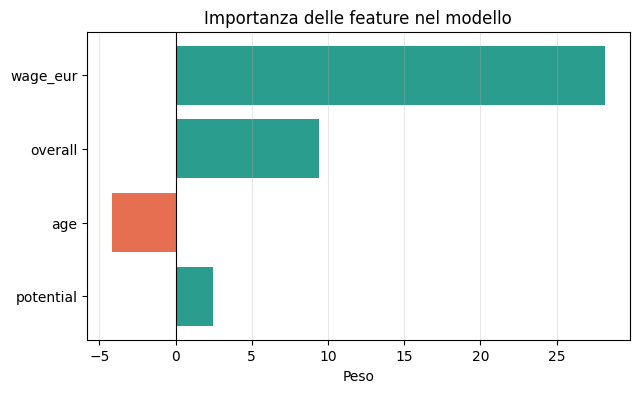

In [6]:
# Creiamo la figura
plt.figure(figsize=(7, 4))

# Assegniamo un colore a ogni barra:
# verde per effetto positivo, rosso per effetto negativo
colors = ["#2a9d8f" if w > 0 else "#e76f51" 
          for w in tabella["peso"]]

# Disegniamo le barre orizzontali (una per ogni feature)
plt.barh(tabella["feature"], tabella["peso"], color=colors)

# Linea verticale in corrispondenza di 0:
# separa i contributi positivi da quelli negativi
plt.axvline(0, color="black", linewidth=0.8)

# Etichette e titolo
plt.xlabel("Peso")
plt.title("Importanza delle feature nel modello")

# Mettiamo la feature più importante in alto
plt.gca().invert_yaxis()

# Aggiungiamo una griglia leggera sull'asse orizzontale
plt.grid(True, axis="x", alpha=0.3)

plt.show()


Il grafico mostra in modo molto chiaro come il modello combina le diverse informazioni per stimare il valore di mercato. La variabile più influente è il salario, con un peso nettamente superiore alle altre. Questo è un risultato interessante ma anche intuitivo: **lo stipendio di un giocatore è spesso già una sintesi della sua qualità e del suo valore percepito dal mercato**, quindi il modello lo utilizza come segnale molto forte. Segue l’overall, che ha un peso positivo significativo: conferma quanto avevamo visto all’inizio, cioè che il livello tecnico attuale è uno dei fattori principali nel determinare il valore. Il potential ha un contributo positivo ma molto più contenuto. Questo suggerisce che, pur essendo rilevante, **il talento futuro pesa meno rispetto alla qualità attuale** e al contesto economico rappresentato dal salario. Infine, l’età ha un peso negativo: a parità delle altre variabili, un aumento dell’età tende a ridurre la stima del valore. Questo è coerente con l’idea che **il mercato premi giocatori più giovani**, soprattutto a parità di livello.

## Oltre la linearità

Finora abbiamo utilizzato modelli lineari, prima con una sola variabile e poi con più feature contemporaneamente. Abbiamo visto che la regressione multipla permette di combinare diversi indizi e migliorare le previsioni, ma resta comunque basata su un’ipotesi precisa: che la relazione tra input e output sia lineare. Osservando i dati e i residui, però, emerge che questa ipotesi non è sempre sufficiente. **Le variabili possono interagire tra loro in modo più complesso**, e il loro effetto sul valore di mercato può non essere semplicemente proporzionale. 

### Aumentiamo i parametri

Una prima estensione naturale è la **regressione polinomiale**. L’idea è quella di arricchire il modello **introducendo nuove feature** ottenute come potenze e combinazioni delle variabili originali. Ad esempio, a partire da variabili come età, overall e potential, possiamo aggiungere termini come:

$\displaystyle x_1^2, \quad x_2^2, \quad x_1 x_2, \quad \dots$

Il modello diventa quindi:

$\displaystyle \hat{y} = w_1 x_1 + w_2 x_2 + w_3 x_1^2 + w_4 x_2^2 + w_5 x_1 x_2 + \dots + b$

In questo modo, pur **mantenendo una struttura lineare nei parametri**, il modello è in grado di **rappresentare relazioni non lineari e interazioni tra variabili**. Dal punto di vista geometrico, non stiamo più adattando un semplice iperpiano, ma una superficie più **flessibile**, capace di seguire meglio la struttura dei dati. Con scikit-learn, possiamo generare automaticamente queste nuove feature e applicare lo stesso modello lineare di prima:

In [7]:
# Includiamo la classe per la creazione delle feature polinomiali
from sklearn.preprocessing import PolynomialFeatures

# Definiamo la pipelne aggiungendo il passo per la creazione 
# delle feature polinomiali
model_poly = make_pipeline(
    PolynomialFeatures(degree=5, include_bias=False), 
    MinMaxScaler(),                                   
    SGDRegressor(loss="squared_error",
                 max_iter=1000,
                 eta0=0.01,
                 random_state=12)
)

# Training del modello
model_poly.fit(x_many, y)

# Previsioni
y_pred_poly = model_poly.predict(x_many)

# Valutazione 
mae_poly = mean_absolute_error(y, y_pred_poly)

print(f"MAE modello polinomiale = {mae_poly:.2f} milioni di euro")

MAE modello polinomiale = 1.08 milioni di euro


Il modello polinomiale migliora ulteriormente le prestazioni, portando il MAE poco oltre il milione di euro, quindi circa la metà rispetto al modello lineare iniziale. Questo conferma che introdurre non linearità permette di catturare meglio la struttura dei dati. Tuttavia, questo miglioramento ha un costo: aumentando il grado del polinomio, **il numero di pesi del modello cresce enormemente**. In altre parole, stiamo passando da una semplice retta a una funzione molto complessa, con tanti parametri da stimare. Questo rende il modello **più flessibile**, ma anche **più difficile da interpretare** e anche potenzialmente "subdolo", come vedremo...

### Non tanti parametri, ma un numero imprecisato di parametri!

Un’alternativa molto diversa è rappresentata dagli **alberi di decisione**. A differenza dei modelli che abbiamo visto finora, come la regressione lineare o polinomiale, gli alberi di decisione vengono spesso classificati come **metodi non parametrici**. Nei modelli lineari, infatti, fissiamo a priori la forma della funzione:

$\displaystyle \hat{y} = w_1 x_1 + \dots + w_d x_d + b$

e il numero di parametri cresce con il numero di feature. Nel caso polinomiale, questo numero può diventare molto grande perché introduciamo molte nuove variabili. Negli alberi di decisione, invece, **non imponiamo una forma della funzione** e **non fissiamo in anticipo il numero di parametri**. Il modello procede per domande successive, restringendo progressivamente il campo. Parte da una domanda generale, ad esempio:

"Il giocatore ha un overall alto?"

In funzione della risposta, si sposta su un'altra domanda che restringe ulteriormente il campo e si focalizza su una predizione più specifica. Ad esempio:

"È giovane?"
"Ha un potential alto?"
"Ha uno stipendio elevato?"

Alla fine di questo percorso, che può essere più o meno profondo, si arriva ad un gruppo omogeneo di giocatori, con caratteristiche simili a quelle del giocatore da stimare e si assegna una previsione basata sui valori reali di quel gruppo. Il nome del metodo deriva dal fatto che questa procedura di domande successive ricorda un albero, con rami che si diramano in base alle risposte. In questo modo, invece di una singola regola valida per tutti, il modello costruisce tante regole locali, ciascuna valida per un certo tipo di giocatore. Il numero di "parametri" (cioè le regole dell’albero) emerge quindi dal processo di training. In questo senso un metodo non parametrico non ha un numero fisso di parametri deciso a priori, ma lascia che sia il dataset a determinare la complessità del modello. Questo rende gli alberi **estremamente flessibili**: possono adattarsi a strutture complesse senza dover espandere esplicitamente lo spazio delle feature, come avviene nella regressione polinomiale. Scikit-learn fornisce una classe chiamata **DecisionTreeRegressor** che implementa questo tipo di modello. Vediamo come usarla:

In [8]:
# Importiamo la classe per l'albero di decisione
from sklearn.tree import DecisionTreeRegressor

# Creiamo il modello ad albero
tree_model = DecisionTreeRegressor(random_state=12)

# Training
tree_model.fit(x_many, y)

# Previsioni
y_pred_tree = tree_model.predict(x_many)

# Valutazione
mae_tree = mean_absolute_error(y, y_pred_tree)

print(f"MAE albero di decisione = {mae_tree:.2f} milioni di euro")

MAE albero di decisione = 0.33 milioni di euro


Caspita! Il modello ad albero sembra essere un vero campione, con un MAE molto basso. Questo è un risultato sorprendente,l’albero è riuscito a catturare la complessità dei dati in modo molto efficace, adattandosi alle relazioni non lineari e alle interazioni tra le variabili. Tuttavia, come vedremo, questo risultato apparentemente ottimo nasconde un problema molto serio: il modello è **troppo flessibile** e si è adattato troppo bene ai dati, perdendo una capacità importante di cui non abbiamo ancora parlato, e che vedremo nel prossimo notebook: la **generalizzazione**.

## Facciamo scouting, di nuovo!

Chiudiamo il notebook tornando al nostro problema, ma con uno sguardo più consapevole. Abbiamo costruito modelli sempre più ricchi: prima con un solo indizio, poi con più feature, e infine con modelli non lineari. Ora vogliamo vedere come cambia concretamente il comportamento dello scout. Prendiamo alcuni giocatori a caso e, per ciascuno, mettiamo a confronto le previsioni dei modelli:

In [9]:
# Estraiamo 10 giocatori a caso
sample = dataset.sample(10).copy()

# Usiamo i vari modelli per fare le previsioni su questi giocatori
sample["pred_simple"] = model_single.predict(sample[["overall"]])
sample["pred_many"] = pipeline_model_many_norm.predict(sample[features])
sample["pred_poly"] = model_poly.predict(sample[features])
sample["pred_tree"] = tree_model.predict(sample[features])

# Prendiamo anche i valori reali
sample["value"] = sample["value_mln_eur"]

# Calcoliamo gli errori dei modelli 
sample["error_simple"] = sample["pred_simple"] - sample["value"]
sample["error_many"] = sample["pred_many"] - sample["value"]
sample["error_poly"] = sample["pred_poly"] - sample["value"]
sample["error_tree"] = sample["pred_tree"] - sample["value"]

# Mostriamo il confronto
sample[[
    "short_name",
    "age",
    "overall",
    "potential",
    "wage_eur",
    "value",
    "error_simple",
    "error_many",
    "error_poly",
    "error_tree"
]].round(2)

,short_name,age,overall,potential,wage_eur,value,error_simple,error_many,error_poly,error_tree
13763,F. Ayala,32,62,62,700.0,0.14,0.41,-1.15,0.00,-0.04
14713,A. Abqar,22,61,71,3000.0,0.05,0.03,1.13,0.08,0.72
5943,T. Skarke,24,69,72,7000.0,4.47,-0.72,-1.20,-1.98,0.00
5843,Luismi,29,69,69,5000.0,1.97,1.78,0.05,-0.62,-0.59
18214,N. Bergmark,19,54,62,500.0,0.05,-3.18,-0.83,1.00,0.00
13231,U. Meleke,22,63,74,3000.0,0.96,0.04,0.84,-0.38,0.31
8303,J. Cascante,27,67,70,3000.0,0.25,2.59,1.42,0.70,0.99
10557,M. Osores,24,65,73,3000.0,1.34,0.58,0.53,-0.52,1.26
14238,A. Ito,22,62,68,2000.0,0.48,0.06,0.60,-0.03,0.59
15621,P. Krätschmer,24,60,66,850.0,0.05,-0.42,-0.00,0.04,0.00


Risultati così precisi sono davvero incredibili, il modello ad albero è praticamente perfetto, ma come spesso accade davanti a risultati straordinari, è meglio essere cauti, alzare un certo livello di scetticismo e non lasciarsi abbagliare dai numeri. Aspettiamo a correre dal direttore sportivo sbandierando uno scout automatico infallibile, c'è qualcosa di subdolo da considerare. Di cosa si tratta? Stiamo davvero catturando una relazione generale, o stiamo semplicemente adattandoci troppo bene ai dati che abbiamo visto?

> **Cosa dovremmo aver capito** — Lo scout è cresciuto. Abbiamo prima esteso il modello lineare a più variabili contemporaneamente, scoprendo che l'errore diminuisce quando diamo all'algoritmo più indizi. Per confrontare i pesi delle diverse feature abbiamo dovuto standardizzarle, perché numeri su scale diverse non sono direttamente paragonabili. Poi abbiamo allargato lo sguardo oltre la linearità: con la regressione polinomiale aumentiamo la flessibilità del modello aggiungendo nuove feature derivate; con un albero di decisione entriamo in un mondo diverso, in cui non fissiamo a priori la forma del modello ma lasciamo all'algoritmo la libertà di adattarsi ai dati. Sorpresa finale: l'albero ha ottenuto un errore quasi nullo. Troppo bello per essere vero.


> **Cosa faremo adesso** — Quel "troppo bello" è il punto da cui parte il prossimo notebook. Ci chiederemo se un modello che sembra perfetto sui dati che ha visto sappia davvero prevedere cosa succederà su giocatori che non ha mai incontrato. Per scoprirlo introdurremo la distinzione fondamentale tra errore di training ed errore di test, e incontreremo il fenomeno più importante (e più subdolo) del machine learning: l'overfitting.